In [34]:
import numpy as np
from scipy.io import loadmat    #So that we can load in MATLAB files.
from matplotlib.path import Path    #So that we can reproduce MATLAB's inpolygon function.
import matplotlib.pyplot as plt #So that we can plot any borders or points that we want to visualize.
from itertools import combinations  #So that we can generate all combinations of stops for the traveling salesman problem.
import networkx as nx    #So that we can use graph algorithms to solve the traveling salesman problem.
from scipy.sparse import lil_matrix, vstack    #So that we can create sparse matrices for the constraint setting in the traveling salesman problem.
from scipy.optimize import milp #This is our mixed integer linear program solver
from scipy.optimize import LinearConstraint #This is our constraint object which said solver needs as an argument.
from scipy.optimize import Bounds #This is our bounds object which the milp solver needs as an argument.

In [35]:
border_data = loadmat("usborder.mat")   #Loads in the MATLAB US Border file which they use to demonstrate solving this problem.

x = border_data["x"].ravel()    #Convert the objects into 1D arrays for use in the optimization problem.
y = border_data["y"].ravel()

print(border_data.keys())    #See what the MATLAB file contains. The keys are the variable names, and the values are the data.

dict_keys(['__header__', '__version__', '__globals__', 'x', 'y', 'xx', 'yy', 'TICTOC'])


In [36]:
#Defines the US Border as a Path object, which allows us to check if points are inside the border.

border_vertices = np.column_stack((x, y))   #Combine the x and y coordinates into a single array of border vertices.
us_border = Path(border_vertices)   #Create a Path object from the border vertices, which allows us to check if points are inside the border.
point = np.array([[0.8, 0.4]])  #Define a point to check if it is inside the US border.
is_inside = us_border.contains_points(point)[0]

print(is_inside)

True


In [37]:
#Generate a set of random stops that are inside the US border. We will use these stops to solve the traveling salesman problem.
#This is not necessary for the parts of this notebook that are relevant to solving the traveling salesman problem, but it is useful for visualizing the problem and for testing the optimization algorithm.

rng = np.random.default_rng(3)  #Set the random number generator seed for reproducibility.

n_stops = 75   #Define the number of stops we want to solve for.
stops = []  #Original list of stops, which will be appended to as we generate new stops.

while len(stops) < n_stops: #While we haven't generated enough stops, keep generating new stops.
    candidate = np.array([  #Generate a candidate stop by randomly sampling from a uniform distribution over the bounding box of the US border.
        rng.random() * 1.5, #The x-coordinate is sampled from a uniform distribution over the range [0, 1.5], which is the bounding box of the US border.
        rng.random()    #The y-coordinate is sampled from a uniform distribution over the range [0, 1]
    ])

    if us_border.contains_point(candidate): #Keep the candidate stop if it is inside the US border, otherwise discard it and generate a new candidate.
        stops.append(candidate)

stops = np.asarray(stops)   #Convert the list of stops into a NumPy array for easier manipulation and analysis.

stops_lon = stops[:, 0]   #Extract the longitude (x-coordinate) of each stop from the first column of the stops array. We'll need these coordinates to plot the stops on a map of the US border.
stops_lat = stops[:, 1]   #Extract the latitude (y-coordinate) of each stop from the second column of the stops array.

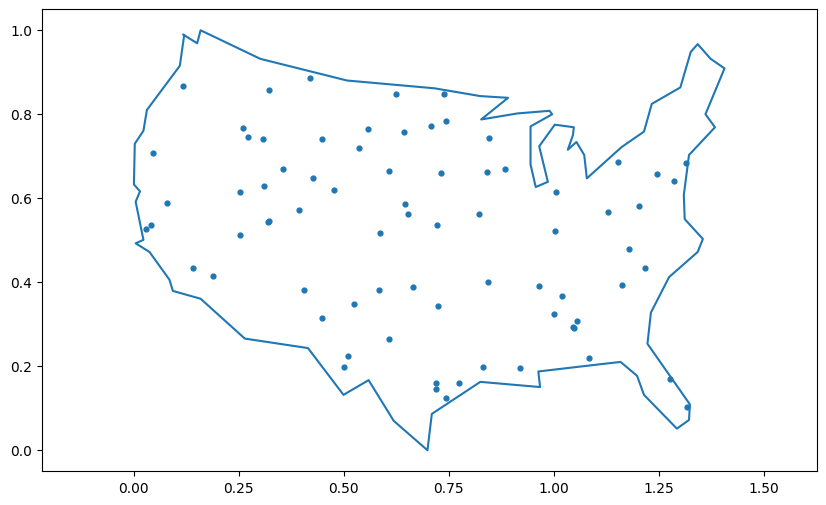

In [38]:
#Plot the US border and the generated stops to visualize the problem.

plt.figure(figsize=(10, 6)) #Create a new figure with a specified size
plt.plot(x, y)  #Plot the US border using the x and y coordinates which we got from the us_border object which we created from the MATLAB file.
plt.scatter(stops_lon, stops_lat, s=12) #Plot the generated stops as a scatter plot, with a specified marker size.
plt.axis("equal")   #Set the aspect ratio of the plot to be equal, so that the x and y axes are scaled equally. So that the US border is recognizable and not distorted.
plt.show()

In [39]:
x.size

73

In [40]:
#Now we get to generate a list of all combinations of stops that we want to consider for the traveling salesman problem. We will use these combinations to generate a distance matrix, which we will then use to solve the traveling salesman problem.

idxs = np.array(list(combinations(range(len(stops[:,0])), 2)))    #Combinations lists all possible pairs of stops from the list of stops and number we want of stops per combination (2; start and finish). The output is a list of tuples, where each tuple contains the indices of the two stops in the combination. We convert this list of tuples into a NumPy array for easier manipulation and analysis.

distances = np.linalg.norm(stops[idxs[:,0], :] - stops[idxs[:,1], :], axis=1)   #Calculate the Euclidean distance between each pair of stops. The differences between the coordinates of the stops are computed, and then the norm (distance) is calculated along the specified axis (axis=1 for row-wise operation).

In [41]:
G = nx.Graph()    #Initialize an empty graph to represent the traveling salesman problem.

G.add_edges_from([(idxs[i,0], idxs[i,1], {'weight': distances[i]}) for i in range(len(idxs))])    #Add edges to the graph with the corresponding distances as weights.

In [42]:
#Now we get to create a sparse matrix to represent which cities are included in each edge, which begins for us the constraint setting.

Aeq = lil_matrix((n_stops, idxs.shape[0]), dtype=np.int64)   #Create a sparse matrix where each row represents a city and each column represents an edge, with entries indicating whether a city is included in an edge.

#Now we need to populate the matrix using a for loop
for i in range(n_stops):    #For each city,
    which_idxs = np.where((idxs[:,0] == i) | (idxs[:,1] == i))[0]    #Find the indices of the edges that include the current city.
    Aeq[i, which_idxs] = 1    #Set the entries corresponding to the edges that include the current city to 1.

Beq = 2*np.ones(n_stops, dtype=np.int64) #This creates a vector of 2's to help us set the constraint of edges connected per city.

In [43]:
intcon = np.arange(idxs.shape[0])   #In the matlab implementation, this tells us which variables must be integers. It remains to be seen if this is necessary in the Python implementation.


intcon.size

2775

In [44]:
#Make sure we create the lower and upper bounds object correctly to be used in the optimize problem.
lb = np.zeros(idxs.shape[0], dtype=np.int64)   #Lower bound for the decision variables, typically set to 0.
ub = np.ones(idxs.shape[0], dtype=np.int64)    #Upper bound for the decision variables, typically set to 1.

#This linear constraint should say that b <= Aeq * x <= b, which I believe is the correct way to represent equality constraints in the form of a linear constraint.
bounds_binary = np.array([lb, ub]).T
bounds_binary

lc = LinearConstraint(Aeq, Beq, Beq, keep_feasible=True)

bounds_obj = Bounds(lb, ub)

#Solve it as is, which creates subtours.
optimal_subtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)

In [45]:
#Let's check that Ax is within the bounds specified by the linear constraint
Ax = Aeq @ optimal_subtours.x
print("Ax:", Ax)
print("Beq:", Beq)
print("Ax within bounds:", np.all(Ax >= Beq) and np.all(Ax <= Beq))

Ax: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2.]
Beq: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
Ax within bounds: True


In [46]:
#Great, now let's make a solution idxs_solution object
idxs_solution = idxs[optimal_subtours.x.astype(bool)]
print("idxs_solution:\n", idxs_solution)

idxs_solution:
 [[ 0 21]
 [ 0 56]
 [ 1 33]
 [ 1 46]
 [ 2 16]
 [ 2 30]
 [ 3  4]
 [ 3 71]
 [ 4 71]
 [ 5 40]
 [ 5 50]
 [ 6 17]
 [ 6 52]
 [ 7 36]
 [ 7 68]
 [ 8 24]
 [ 8 54]
 [ 9 47]
 [ 9 67]
 [10 50]
 [10 74]
 [11 66]
 [11 72]
 [12 15]
 [12 22]
 [13 58]
 [13 64]
 [14 43]
 [14 49]
 [15 22]
 [16 30]
 [17 52]
 [18 38]
 [18 59]
 [19 29]
 [19 55]
 [20 34]
 [20 48]
 [21 28]
 [23 67]
 [23 72]
 [24 54]
 [25 39]
 [25 73]
 [26 60]
 [26 65]
 [27 37]
 [27 57]
 [28 61]
 [29 55]
 [31 59]
 [31 69]
 [32 62]
 [32 70]
 [33 63]
 [34 48]
 [35 36]
 [35 41]
 [37 57]
 [38 41]
 [39 40]
 [42 73]
 [42 74]
 [43 69]
 [44 45]
 [44 51]
 [45 51]
 [46 68]
 [47 63]
 [49 53]
 [53 66]
 [56 61]
 [58 64]
 [60 65]
 [62 70]]


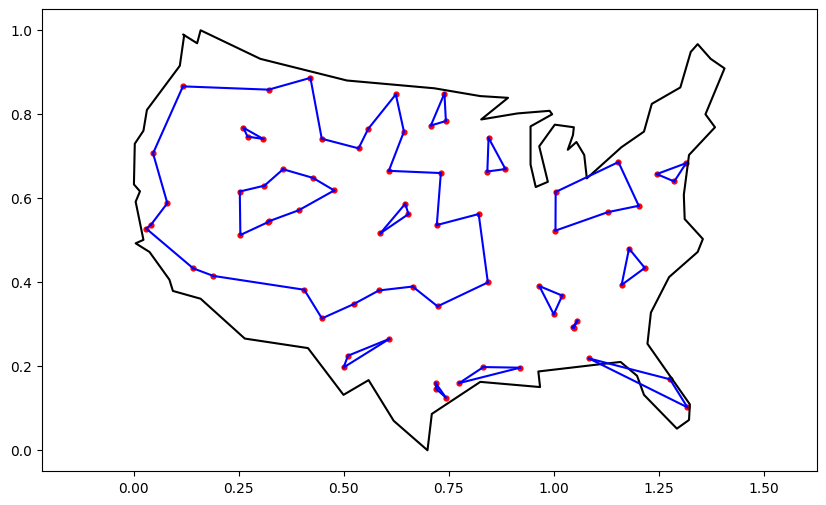

In [47]:
#We need to know the number of subtours in the solution and so we create a graph from the solution edges.
GSol = nx.Graph()
GSol.add_edges_from(idxs_solution)

#Same plot of the map as before
plt.figure(figsize=(10, 6)) #Create a new figure with a specified size
plt.plot(x, y, 'k-')  #Plot the US border using the x and y coordinates which we got from the us_border object which we created from the MATLAB file.
plt.scatter(stops_lon, stops_lat, s=12, c='r') #Plot the generated stops as a scatter plot, with a specified marker size.
plt.axis("equal")   #Set the aspect ratio of the plot to be equal, so that the x and y axes are scaled equally. So that the US border is recognizable and not distorted.

#And now we get to add the edges to the plt plot we had made
for edge in idxs_solution:
    plt.plot([stops_lon[edge[0]], stops_lon[edge[1]]], [stops_lat[edge[0]], stops_lat[edge[1]]], 'b-')
plt.show()

In [48]:
#How many subtours are there?
num_subtours = nx.number_connected_components(GSol)
print(f"Number of subtours: {num_subtours}")
subTours = list(nx.connected_components(GSol))
for i, subtour in enumerate(subTours):
    print(f"Subtour {i+1}: {subtour}")

Number of subtours: 15
Subtour 1: {np.int64(0), np.int64(21), np.int64(56), np.int64(28), np.int64(61)}
Subtour 2: {np.int64(1), np.int64(7), np.int64(9), np.int64(11), np.int64(14), np.int64(18), np.int64(23), np.int64(31), np.int64(33), np.int64(35), np.int64(36), np.int64(38), np.int64(41), np.int64(43), np.int64(46), np.int64(47), np.int64(49), np.int64(53), np.int64(59), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(72)}
Subtour 3: {np.int64(16), np.int64(2), np.int64(30)}
Subtour 4: {np.int64(3), np.int64(4), np.int64(71)}
Subtour 5: {np.int64(5), np.int64(39), np.int64(40), np.int64(73), np.int64(10), np.int64(74), np.int64(42), np.int64(50), np.int64(25)}
Subtour 6: {np.int64(17), np.int64(52), np.int64(6)}
Subtour 7: {np.int64(8), np.int64(24), np.int64(54)}
Subtour 8: {np.int64(12), np.int64(22), np.int64(15)}
Subtour 9: {np.int64(64), np.int64(58), np.int64(13)}
Subtour 10: {np.int64(19), np.int64(29), np.int64(55)}
Subtour 11: {np.int64(48),

In [49]:

#Now I understand how the matlab algorithm works to turn the wish to elimitate subtours into rigorous inequality constraints.
#The key is to group up nodes into their subtour groups and say that among those edges representing possible connections between those nodes, 
#the sum of the selected edges must be less than the number of nodes in that subtour group. This prevents the formation of subtours and ensures that the solution forms a single tour covering all nodes.
#What if I define this function just so calling it may be easier?

#This matrix is empty now but it will soon have one row for each subtour we're intent on avoiding.
A = lil_matrix((0,idxs.shape[0]), dtype=np.int8) 
#This array will hold the bounds for how many of the edges from matrix A we allow, effectively restricting loops to form among those subtour groups.
b = np.array([], dtype=np.int8) 

#Our friend here will count through the rows of A and b as we make them.
rowIdx=0

def add_subtour_constraints(A, b, rowIdx, subTours, idxs):

    num_subtours = len(subTours)
    #Allocate the data for the new constraint on the current subtours.
    b = np.concatenate([b, np.zeros([num_subtours], dtype=np.int64)])  
    #This is scipy.sparse.vstack by the way. Not numpy.vstack. We need to set the format as "lil" 
    #because default output of coo_matrix does not support item assignment.
    A = vstack(
        [A, lil_matrix((num_subtours, idxs.shape[0]), dtype=np.int64)],
        format="lil"
    )   

    #This friend i will go through each of the current subtours we need to deal with.
    for i in range(num_subtours):

        #List all the nodes in the current subtour
        subTourIdx = list(subTours[i]) 
        #List all possible pairs of stops within the current subtour
        variations = np.array(list(combinations(range(len(subTourIdx)), 2)))   

        #This j iterates through the variations of the subtour edges.
        for j in range(len(variations)):

            #The numpy row version of the edge between the two nodes at this subtour edge variation.
            edge = np.array([subTourIdx[variations[j][0]], subTourIdx[variations[j][1]]])
            #Reorder the edge so that the smaller node comes first
            edge = np.sort(edge)

            #Where does this edge show up in the whole idxs array?
            edge_idx = np.where((idxs[:,0] == edge[0]) & (idxs[:,1] == edge[1]))[0]

            #For the subgroup associated with the given row of A, the edge_edx is among the edges we want to limit to avoid this subgroup from forming.
            A[rowIdx, edge_idx] = 1  
        #Set the corresponding bound for this subtour in b
        b[rowIdx] = len(subTourIdx) - 1

        #Move to the next row for the next subtour
        rowIdx += 1

    return A, b, rowIdx

[A, b, rowIdx] = add_subtour_constraints(A, b, rowIdx, subTours, idxs)

In [50]:
#Now we get to add A and b as inequality constraints to our original
#Let's also define this as its own function for easy iterability.
#This guy combines the equality constraints (Aeq, Beq) with the inequality constraints (A, b) into a single system.

#To call in other kernels note you need to not just create the subtour constraints A and b, but also the graph-wide objects Aeq, Beq, distances, idxs, bounds_obj
def solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj, pr='y'):
    #Make sure the print parameter is y or n
    if pr not in ['y', 'yg', 'n']:
        raise ValueError("print parameter must be 'y' or 'n'")

    AeqA = vstack(
        [Aeq, A],
        format = "lil"
    )

    #No lower bounds for the inequality constraints, so we set them to zero
    bl = np.concatenate(
        [Beq, np.zeros((A.shape[0]))]
    )

    #The inequality constraints act as upper bounds.
    bu = np.concatenate(
        [Beq, b]
    )

    #Make sure our sizes are working together okay
    assert bl.shape[0] == bu.shape[0]
    assert AeqA.shape[0] == bl.shape[0]

    #Create a linear constraint object for the combined equality and inequality constraints
    lc = LinearConstraint(AeqA, bl, bu, keep_feasible=True)

    #And cross our fingers and hand it off to the MILP solver
    optimalLessSubtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)

    #Let's check that Ax is within the bounds specified by the linear constraint
    if pr in ['y', 'yg']:
        Ax = Aeq @ optimalLessSubtours.x
        print("Ax:", Ax)
        print("Beq:", Beq)
        print("Ax within bounds:", np.all(np.round(Ax, 1) == Beq))

        #Let's also check the inequality constraints
        Ax_ineq = (np.round((AeqA @ optimalLessSubtours.x),1)).astype(int)  # Convert to a dense array for easier manipulation
        print("Ax_ineq:", Ax_ineq)
        print("bu:", bu)
        print("Ax_ineq within bounds:", np.all(Ax_ineq >= bl) and np.all(Ax_ineq <= bu))

    tempGSol = nx.Graph()
    tempGSol.add_edges_from(idxs[np.round(optimalLessSubtours.x, 1).astype(bool)])

    if max(dict(tempGSol.degree()).values()) > 2:
        worked = False

    else:
        worked = True

    #Took out the plotting of the subtours for simplicity

    subTours = list(nx.connected_components(tempGSol))

    if pr in ['y', 'yg']:
        for i, subtour in enumerate(subTours):
            print(f"Subtour {i+1}: {subtour}")

    return tempGSol, subTours, worked

[tempGSol, subTours, worked] = solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj, pr='yg')


Ax: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2.]
Beq: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
Ax within bounds: True
Ax_ineq: [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  3 20  2  2  8  2  2  2  2  2  2  1  2  2  2]
bu: [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  4 24  2  2  8  2  2  2  2  2  2  2  2  2  2]
Ax_ineq within bounds

In [51]:
[A, b, rowIdx] = add_subtour_constraints(A, b, rowIdx, subTours, idxs)
[tempGSol, subTours, worked] = solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj, pr='yg')

Ax: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2.]
Beq: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
Ax within bounds: True
Ax_ineq: [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  3 19  2  2  8  2  2  2  2  2  2  2  2  2  2 29 28  4  4  2]
bu: [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  4 24  2  2  8  2  2  2  2  2  2  2  2  2  2 30 30  

In [52]:
ASave = A
bSave = b
subToursSave = subTours

In [53]:
A = ASave
b = bSave
subTours = subToursSave

In [54]:
# while len(subTours)>1:    
#     [A, b, rowIdx] = add_subtour_constraints(A, b, rowIdx, subTours, idxs)
#     [tempGSol, subTours, worked] = solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj, pr='yg')

In [72]:
def full_tsp(stops, open=False, endpoints=None):
    #Make sure that the endpoints the user gave, if they gave any, are valid.
    if endpoints is not None:
        assert len(endpoints) <= 2, "Endpoints should be a list or tuple of at most two elements."
        assert all(0 <= e < stops.shape[0] for e in endpoints), "Endpoints should be valid stop indices."

    if endpoints is not None:
        startNode = endpoints[0]
        endNode = endpoints[1] if len(endpoints) == 2 else None
    else:
        startNode, endNode = None, None

    n_stops = stops.shape[0]    #Get the number of stops from the shape of the stops array.

    #Now we get to generate a list of all combinations of stops that we want to consider for the traveling salesman problem. We will use these combinations to generate a distance matrix, which we will then use to solve the traveling salesman problem.

    #Combinations lists all possible pairs of stops from the list of stops and number we want of stops per combination (2; start and finish). The output is a list of tuples, where each tuple contains the indices of the two stops in the combination. We convert this list of tuples into a NumPy array for easier manipulation and analysis.
    idxs = np.array(list(combinations(range(len(stops[:,0])), 2)))    
    #Calculate the Euclidean distance between each pair of stops. The differences between the coordinates of the stops are computed, and then the norm (distance) is calculated along the specified axis (axis=1 for row-wise operation).
    distances = np.linalg.norm(stops[idxs[:,0], :] - stops[idxs[:,1], :], axis=1)   

    #Now we get to create a sparse matrix to represent which cities are included in each edge, which begins for us the constraint setting.

    Aeq = lil_matrix((n_stops, idxs.shape[0]), dtype=np.int8)   #Create a sparse matrix where each row represents a city and each column represents an edge, with entries indicating whether a city is included in an edge.

    #Now we need to populate the matrix using a for loop
    for i in range(n_stops):    #For each city,
        which_idxs = np.where((idxs[:,0] == i) | (idxs[:,1] == i))[0]    #Find the indices of the edges that include the current city.
        Aeq[i, which_idxs] = 1    #Set the entries corresponding to the edges that include the current city to 1.

    Beq = 2*np.ones(n_stops, dtype=np.int64) #This creates a vector of 2's to help us set the constraint of edges connected per city.

    #Make sure we create the lower and upper bounds object correctly to be used in the optimize problem.
    lb = np.zeros(idxs.shape[0], dtype=np.int64)   #Lower bound for the decision variables, typically set to 0.
    ub = np.ones(idxs.shape[0], dtype=np.int64)    #Upper bound for the decision variables, typically set to 1.

    #This linear constraint should say that b <= Aeq * x <= b, which I believe is the correct way to represent equality constraints in the form of a linear constraint.
    bounds_binary = np.array([lb, ub]).T
    bounds_binary

    lc = LinearConstraint(Aeq, Beq, Beq, keep_feasible=True)

    bounds_obj = Bounds(lb, ub)

    #Do we mean to solve open, or closed?
    if open:
        [tempGSol, subTours, worked] = Solve_With_Subtour_Open(Aeq, Beq, A=None, b=None, distances=distances, idxs=idxs, bounds_obj=bounds_obj, startNode=None, endNode=None, pr='n')

    else:
        #Solve it as is, which creates subtours.
        optimal_subtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)
        tempGSol = nx.Graph()
        tempGSol.add_edges_from(idxs[np.round(optimal_subtours.x, 1).astype(bool)])

    A = lil_matrix((0,idxs.shape[0]), dtype=np.int8) 
    #This array will hold the bounds for how many of the edges from matrix A we allow, effectively restricting loops to form among those subtour groups.
    b = np.array([], dtype=np.int8) 

    #Our friend here will count through the rows of A and b as we make them.
    rowIdx=0

    num_subtours = nx.number_connected_components(tempGSol)
    subTours = list(nx.connected_components(tempGSol))

    while len(subTours)>1:    
        [A, b, rowIdx] = add_subtour_constraints(A, b, rowIdx, subTours, idxs)
        if not open:
            [tempGSol, subTours, worked] = solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj)
        else:
            [tempGSol, subTours, worked] = Solve_With_Subtour_Open(Aeq, Beq, A, b, distances, idxs, bounds_obj, startNode=startNode, endNode=endNode)
    return tempGSol, worked

In [56]:
# [GSol, worked] = full_tsp(stops)

In [57]:
def printGraph(stops, GSol, figsize=(10, 6), x=None, y=None, border=None):
    stops_lon = stops[:, 0]   #Extract the longitude (x-coordinate) of each stop from the first column of the stops array. We'll need these coordinates to plot the stops on a map of the US border.
    stops_lat = stops[:, 1]   #Extract the latitude (y-coordinate) of each stop from the second column of the stops array.
    plt.figure(figsize=figsize) #Create a new figure with a specified size
    if x is not None and y is not None:
        plt.plot(x, y, 'k-')  #Plot the US border using the x and y coordinates which we got from the us_border object which we created from the MATLAB file.
    elif border is not None:
        plt.plot(border[:, 0], border[:, 1], 'k-')  #Plot the US border using the border Path object if x and y are not provided.
    plt.scatter(stops_lon, stops_lat, s=12) #Plot the generated stops as a scatter plot, with a specified marker size.
    plt.axis("equal")   #Set the aspect ratio of the plot to be equal, so that the x and y axes are scaled equally. So that the US border is recognizable and not distorted.

    for edge in GSol.edges():
        plt.plot([stops_lon[edge[0]], stops_lon[edge[1]]], [stops_lat[edge[0]], stops_lat[edge[1]]], 'b-')

    plt.show()

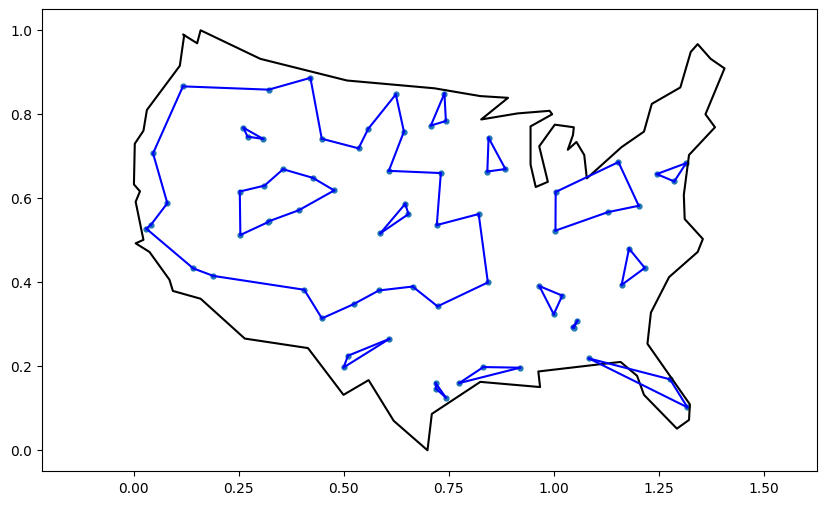

In [58]:
printGraph(stops, GSol, x=x, y=y)

In [59]:
#Let's make sure it runs with fewer stops now, before we move it to a new file as a helper function.

def generateStops(num_stops, seed=None, border=None):
    if border is not None:
        if not isinstance(border, Path):
            if type(border) is not tuple:
                raise TypeError("border must be either a matplotlib.path.Path or a tuple")
            else:
                border = Path(border)

    if seed is not None:
        np.random.seed(seed)

    stops = []
    while len(stops) < num_stops: #While we haven't generated enough stops, keep generating new stops.
        candidate = np.array([  #Generate a candidate stop by randomly sampling from a uniform distribution over the bounding box of the US border.
            rng.random() * 1.5, #The x-coordinate is sampled from a uniform distribution over the range [0, 1.5], which is the bounding box of the US border.
            rng.random()    #The y-coordinate is sampled from a uniform distribution over the range [0, 1]
        ])

        if not border or border.contains_point(candidate): #Keep the candidate stop if it is inside the US border, otherwise discard it and generate a new candidate.
            stops.append(candidate)

    return np.array(stops)

In [60]:
# [GSol, worked] = full_tsp(stops)
# printGraph(stops, GSol, x=x, y=y)

In [61]:
def Solve_With_Subtour_Open(Aeq, Beq, A=None, b=None, distances=None, idxs=None, bounds_obj=None, startNode=None, endNode=None,pr='y'):
    #Make sure the print parameter is y or n
    if pr not in ['y', 'yg', 'n']:
        raise ValueError("print parameter must be 'y' or 'n'")

    #Make sure that the A and b objects are correct size, if they are given.
    #Only then can you safely combine them with the equality constraints.
    if A is not None:
        assert A.shape[1] == Aeq.shape[1], "A must have the same number of columns as Aeq"
        AeqA = vstack(
            [Aeq, A],
            format = "lil"
        )
    else:
        AeqA = Aeq

    #For this version, we actually need to change the lower bound for Beq to be a vector of ones; beginning and ending nodes willl have just one edge.
    BeqOnes = np.ones_like(Beq)

    if b is not None:
        assert b.shape[0] == A.shape[0], "b must have the same number of rows as A"
        #No lower bounds for the inequality constraints, so we set them to zero
        bl = np.concatenate(
            [BeqOnes, np.zeros((A.shape[0]))]
        )
        #The upper bounds are all 2's, plus the constraints of the observed subtours.
        bu = np.concatenate(
            [Beq, b]
        )
    else:
        bl = BeqOnes
        bu = Beq

    #Everything above -- minus one tweak to bl, was already present appending the inequality constraints as subtour constraints.
    #However, one tweak we made afterwards was that in this function, the subtour constraints may or may not be present. hence the "if A is not None", ditto with "if b is not None"
    #Everything below is related to making the TSP problem open.
    #First, that the total number of edges must now be one less than the number of nodes, since the tour is open.
    #Recover the number of stops (nodes)
    num_stops = Aeq.shape[0]
    #Append a row of ones to the combined equality and inequality constraint matrix to account for the open tour requirement.
    AeqA = vstack(
        [AeqA, np.ones((1, AeqA.shape[1]))],
        format="lil"
    )
    bl = np.concatenate(
        [bl, np.array([num_stops - 1])]
    )
    bu = np.concatenate(
        [bu, np.array([num_stops - 1])]
    )
    if startNode is not None:
        #Make sure that the start node is a valid number
        if not (0 <= startNode < num_stops):
            raise ValueError("startNode must be between 0 and num_stops-1")
        #Set the upper bound for the start node to 1, ensuring it is at one end of the tour
        bu[startNode] = 1

    if endNode is not None:
        #Make sure that the end node is a valid number
        if not (0 <= endNode < num_stops):
            raise ValueError("endNode must be between 0 and num_stops-1")
        #Set the upper bound for the end node to 1, ensuring it is at the other end of the tour
        bu[endNode] = 1

    #Make sure our sizes are working together okay
    assert bl.shape[0] == bu.shape[0]
    assert AeqA.shape[0] == bl.shape[0]

    #Create a linear constraint object for the combined equality and inequality constraints
    lc = LinearConstraint(AeqA, bl, bu, keep_feasible=True)

    #And cross our fingers and hand it off to the MILP solver
    optimalLessSubtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)

    tempGSol = nx.Graph()
    tempGSol.add_edges_from(idxs[np.round(optimalLessSubtours.x, 1).astype(bool)])

    if max(dict(tempGSol.degree()).values()) > 2 and min(dict(tempGSol.degree()).values()) < 1:
        worked = False

    else:
        worked = True

    #Let's check that Ax is within the bounds specified by the linear constraint
    if pr in ['y', 'yg']:
        Ax = Aeq @ optimalLessSubtours.x
        print("Ax:", Ax)

    if max(dict(tempGSol.degree()).values()) > 2:
        worked = False

    else:
        worked = True

    #Took out the plotting of the subtours for simplicity

    subTours = list(nx.connected_components(tempGSol))

    if pr in ['y', 'yg']:
        for i, subtour in enumerate(subTours):
            print(f"Subtour {i+1}: {subtour}")

    return tempGSol, subTours, worked

    

In [73]:
[G, worked] = full_tsp(stops, open=True, endpoints=[0])

Ax: [1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2.]
Subtour 1: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(53), np.int64(55), np.int64(57), np.int64(59), np.int64(61), np.int64(62), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int

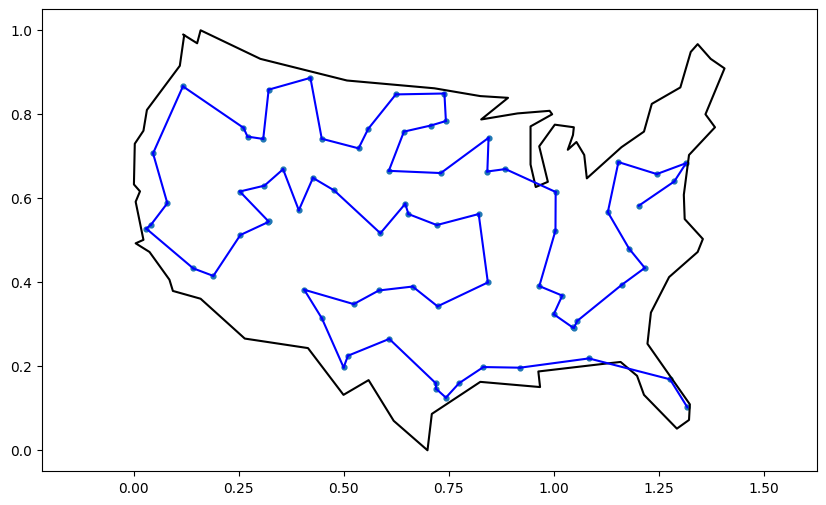

In [74]:
printGraph(stops, G, x=x, y=y)